## Initial exploration of data structure, coverage, and quality

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("../data/raw/share-of-individuals-using-the-internet.csv")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6331 entries, 0 to 6330
Data columns (total 4 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Entity                                      6331 non-null   str    
 1   Code                                        6331 non-null   str    
 2   Year                                        6331 non-null   int64  
 3   Share of the population using the Internet  6331 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 198.0 KB


All columns have 6,331 non-null entries, confirming no data is missing.

In [5]:
data.describe(include="all")

,Entity,Code,Year,Share of the population using the Internet
count,6331,6331,6331.000000,6331.000000
unique,225,225,NaN,NaN
top,Austria,AUT,NaN,NaN
freq,35,35,NaN,NaN
mean,NaN,NaN,2008.200126,31.755286
std,NaN,NaN,9.187751,32.318210
min,NaN,NaN,1990.000000,0.000000
25%,NaN,NaN,2001.000000,1.856490
50%,NaN,NaN,2008.000000,19.370000
75%,NaN,NaN,2016.000000,60.917500


Like it was shown before all columns have the same amount of points. Most common country is Austria, years are from 1990 to 2025 which would explain the frequecy of 35, which could indicate uneven data coverage between countries. However, share of the population using the Internet 25% percenline is only 1,86% which means that there are consistent amount of countries who have or have had a low share, even 50% percenline is 19.37% which can be considered quite low.

In [6]:
data.head()

,Entity,Code,Year,Share of the population using the Internet
0,Afghanistan,AFG,1990,0.000000
1,Afghanistan,AFG,2001,0.004723
2,Afghanistan,AFG,2002,0.004561
3,Afghanistan,AFG,2003,0.087891
4,Afghanistan,AFG,2004,0.105809


Seeing the first 5 values to see how the data is arranged in the dataset and already there is missing data for Afganistan between 1990 and 2001, hence it might be a good idea to consider starting not in 1990 but 2000 as there might be gaps in the data especially in the global south.

In [7]:
print(data['Year'].sort_values().unique())

[1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022 2023 2024 2025]


No years are consistently missing, which means that the gaps in data are at the country level, which should be taken into account, or aggregating it into regional data would make it more reliable

In [8]:
print(data['Entity'].nunique())

225


This implies that there are countries and teritories in the dataset, as UN only recognizes 195 countries.

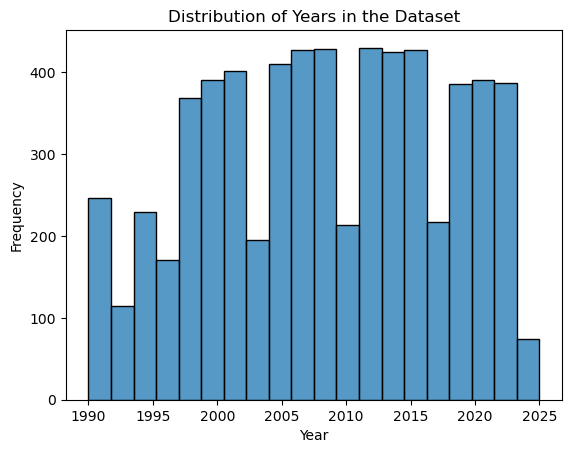

In [9]:
fig, ax = plt.subplots()
sns.histplot(data=data, x="Year", bins=20, ax=ax)
ax.set_title("Distribution of Years in the Dataset")
ax.set_xlabel("Year")
ax.set_ylabel("Frequency")
plt.show()

The distribution shows a clear increase in data density from 2000 onwards, with the pre-2000 period being significantly underrepresented. This supports the decision to scope the analysis to 2000–2025, where coverage across low-income countries becomes reliable enough to draw meaningful comparisons.

Top 10 countries with the most data points:
Index(['Austria', 'Belgium', 'Brazil', 'Denmark', 'France', 'Germany',
       'Greece', 'Hungary', 'Israel', 'Italy'],
      dtype='str', name='Entity')


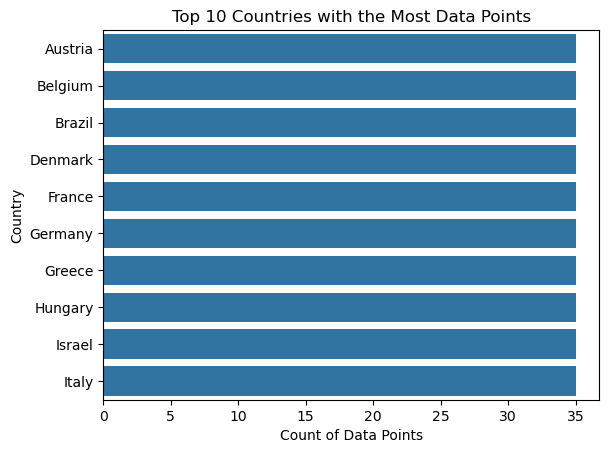

In [10]:
country_counts = data['Entity'].value_counts()
top_countries = country_counts.head(10).index
print("Top 10 countries with the most data points:")
print(top_countries)
data_top_countries = data[data['Entity'].isin(top_countries)]

fig, ax = plt.subplots()
sns.countplot(data=data_top_countries, y='Entity', ax=ax, order=top_countries)
ax.set_title("Top 10 Countries with the Most Data Points")
ax.set_xlabel("Count of Data Points")
ax.set_ylabel("Country")
plt.show()

Top ten countries with the most data points as implied from before are bigger, stronger economies with more stable governments, hence it could focus on the avaliablity of internet and measuring the avaliablity consistenly.

Bottom 10 countries with the least data points:
Index(['North Korea', 'British Virgin Islands', 'South Sudan', 'Nauru',
       'Palau', 'Curacao', 'Kosovo', 'American Samoa',
       'Northern Mariana Islands', 'Turks and Caicos Islands'],
      dtype='str', name='Entity')


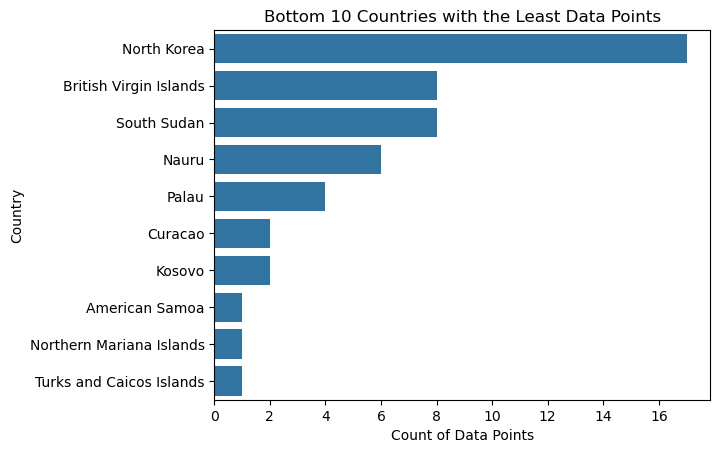

In [11]:
bottom_countries = country_counts.tail(10).index
print("Bottom 10 countries with the least data points:")
print(bottom_countries)
data_bottom_countries = data[data['Entity'].isin(bottom_countries)]

fig, ax = plt.subplots()
sns.countplot(data=data_bottom_countries, y='Entity', ax=ax, order=bottom_countries)
ax.set_title("Bottom 10 Countries with the Least Data Points")
ax.set_xlabel("Count of Data Points")
ax.set_ylabel("Country")
plt.show()

Bottom 10 Countries with the least data points are the small island nations, countries with recent independence or have been ravaged by war, hence the focus of the countries might not have been data collection and expanding internet avaliablity in the country.